<a href="https://colab.research.google.com/github/Gian890/Computacion_Paralela/blob/main/Ising2D_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Tiempo de equilibración

In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/Simulaciones/resultados_equilibracion.csv'
data =  pd.read_csv(path)

In [4]:
data.head()

,L,T,Sweep,Iteracion_Individual,E_por_sitio,M_por_sitio
0,16,2.0,0,0,-0.609375,0.085938
1,16,2.0,1,256,-0.843750,0.171875
2,16,2.0,2,512,-0.968750,0.117188
3,16,2.0,3,768,-1.093750,0.070312
4,16,2.0,4,1024,-1.109375,0.031250


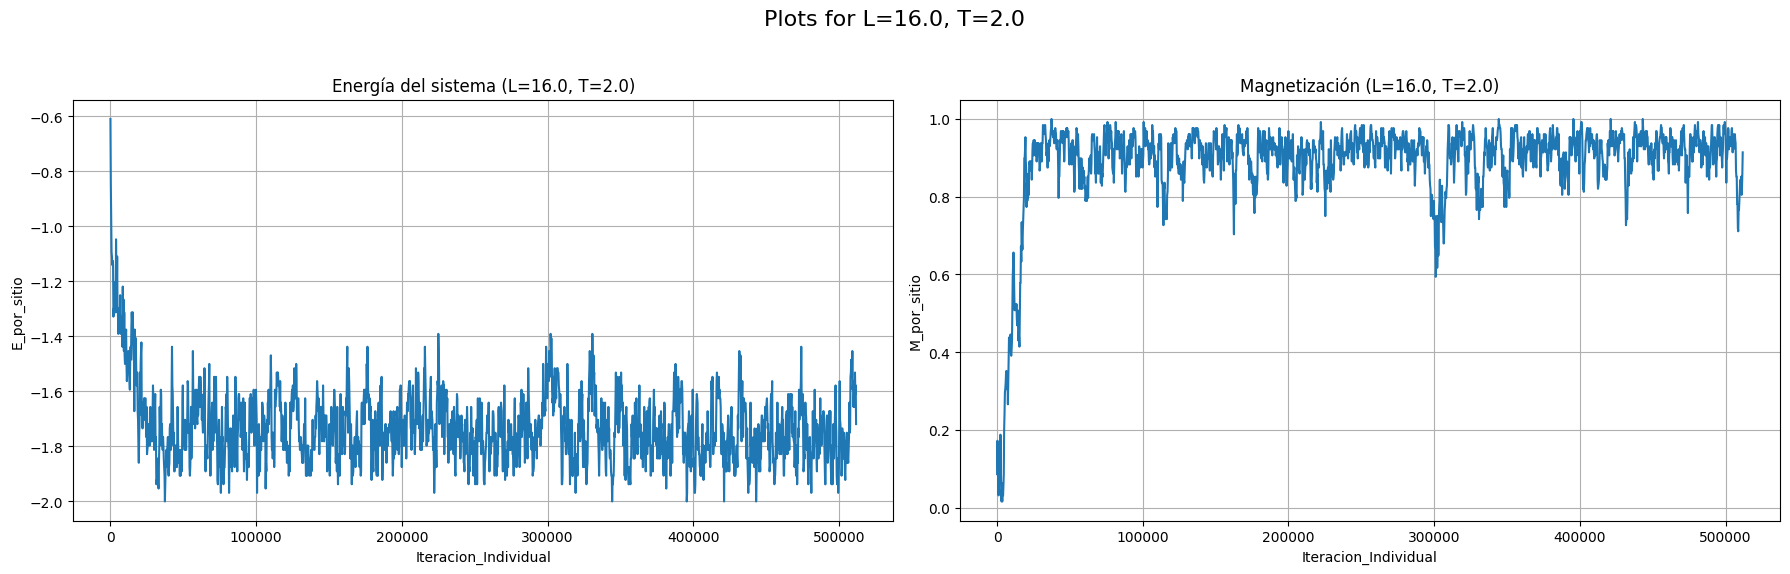

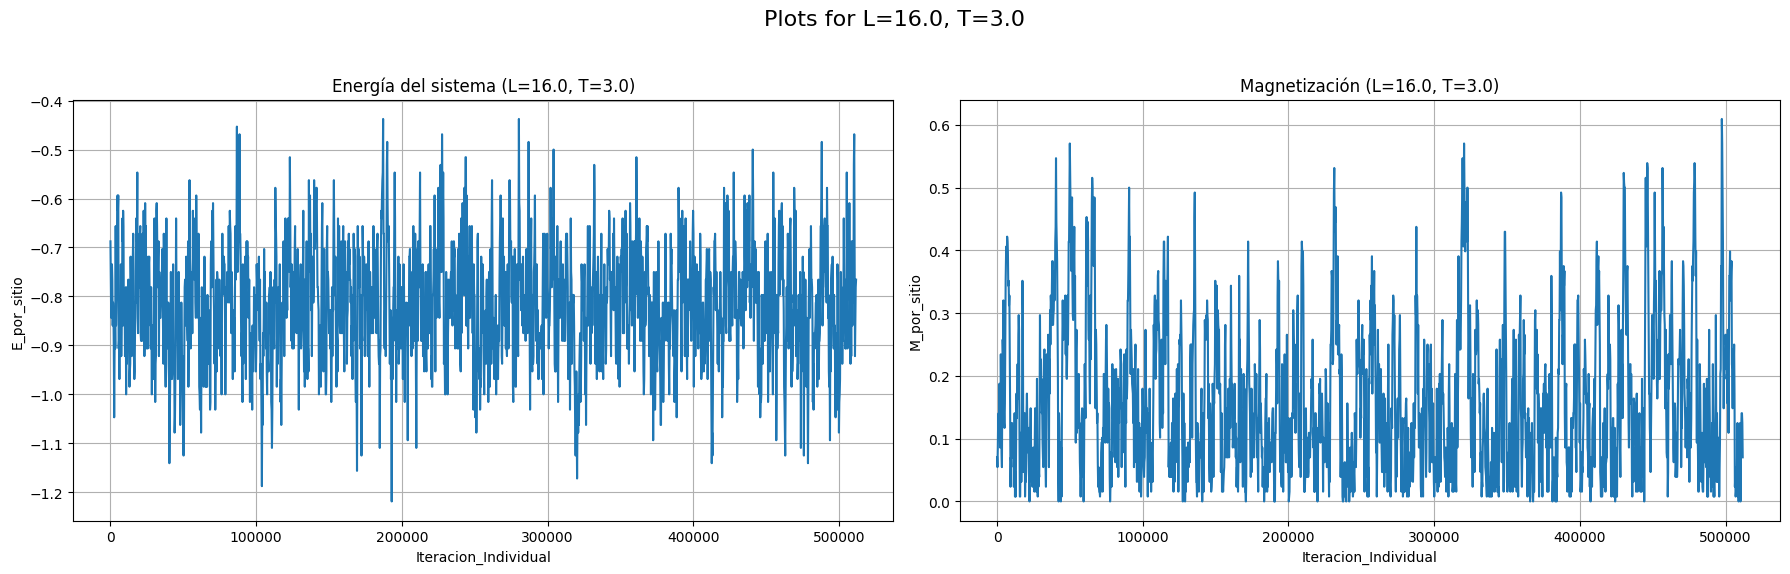

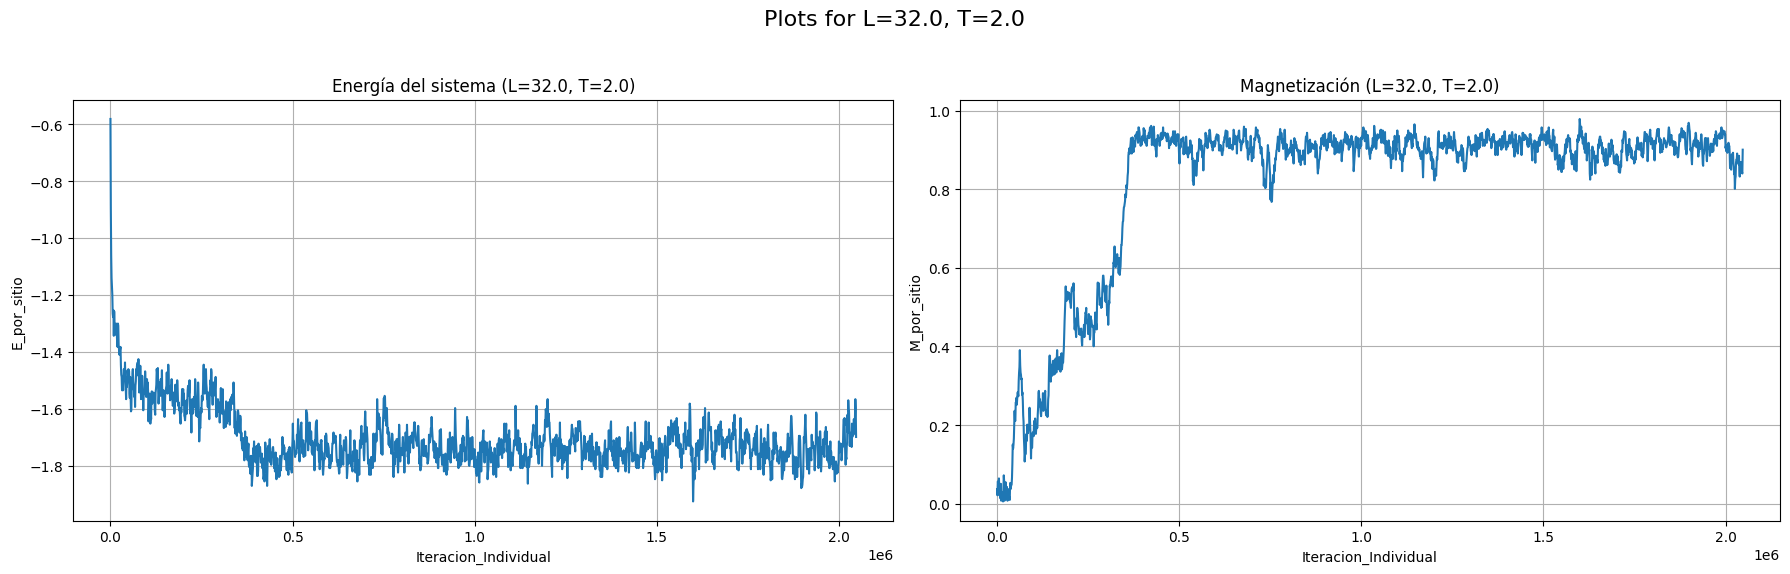

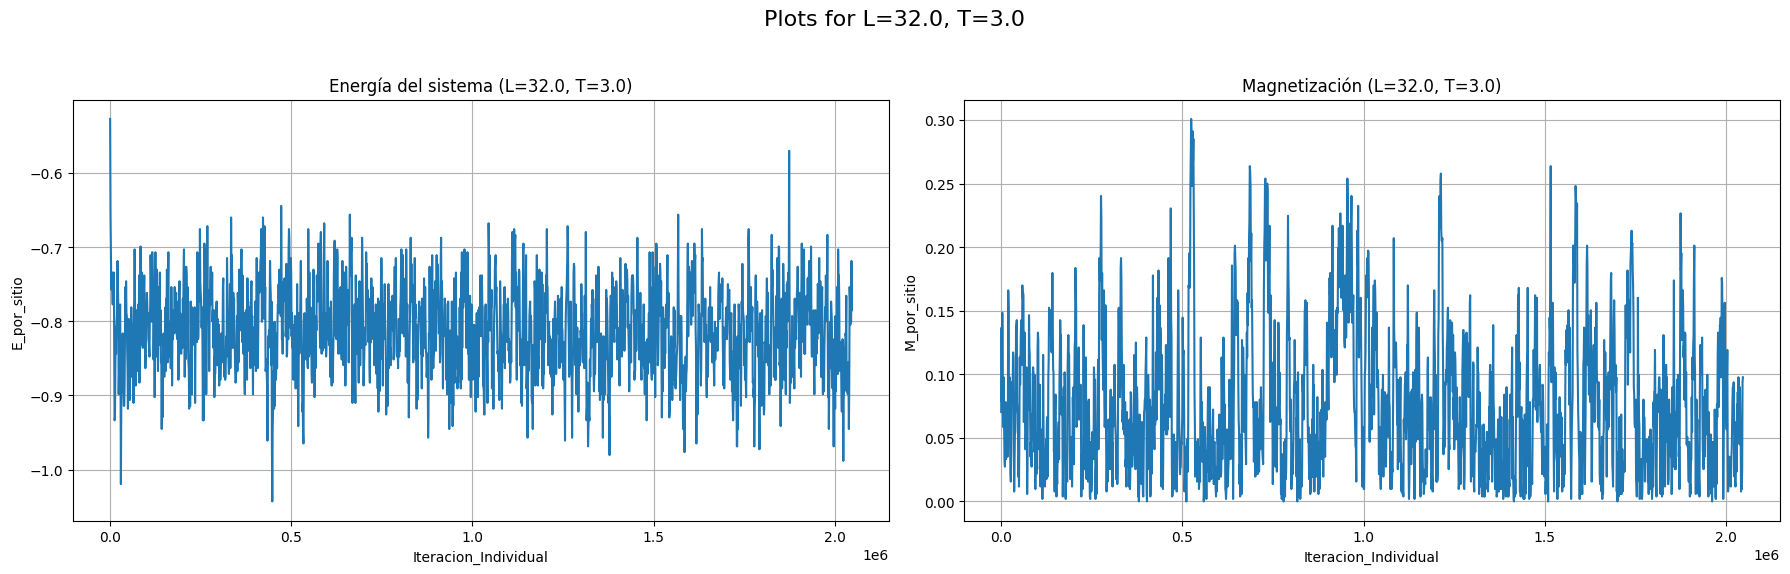

In [5]:
# Get all unique combinations of L and T
unique_LT_combinations = data[['L', 'T']].drop_duplicates().values

for L_val, T_val in unique_LT_combinations:
    # Filter data for the current L and T combination
    filtered_data = data[(data['L'] == L_val) & (data['T'] == T_val)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Plots for L={L_val}, T={T_val}', fontsize=16)

    # Plot E_por_sitio vs Iteracion_Individual
    sns.lineplot(x='Iteracion_Individual', y='E_por_sitio', data=filtered_data, ax=axes[0])
    axes[0].set_title(f'Energía del sistema (L={L_val}, T={T_val})')
    axes[0].set_xlabel('Iteracion_Individual')
    axes[0].set_ylabel('E_por_sitio')
    axes[0].grid(True)

    # Plot M_por_sitio vs Iteracion_Individual
    sns.lineplot(x='Iteracion_Individual', y='M_por_sitio', data=filtered_data, ax=axes[1])
    axes[1].set_title(f'Magnetización (L={L_val}, T={T_val})')
    axes[1].set_xlabel('Iteracion_Individual')
    axes[1].set_ylabel('M_por_sitio')
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


Vemos de los gráficos que el tiempo de equilibracion depende del tamaño del sistema y de la temperatura.

#Función de correlación

In [3]:
path2 = '/content/drive/MyDrive/Colab Notebooks/Simulaciones/resultados_Gr_ejercicio_2.csv'

In [5]:
datos2 = pd.read_csv(path2)
datos2.head()

,T,R,G_R
0,2.65,0,0.999988
1,2.65,1,0.497184
2,2.65,2,0.292051
3,2.65,3,0.187375
4,2.65,4,0.126115


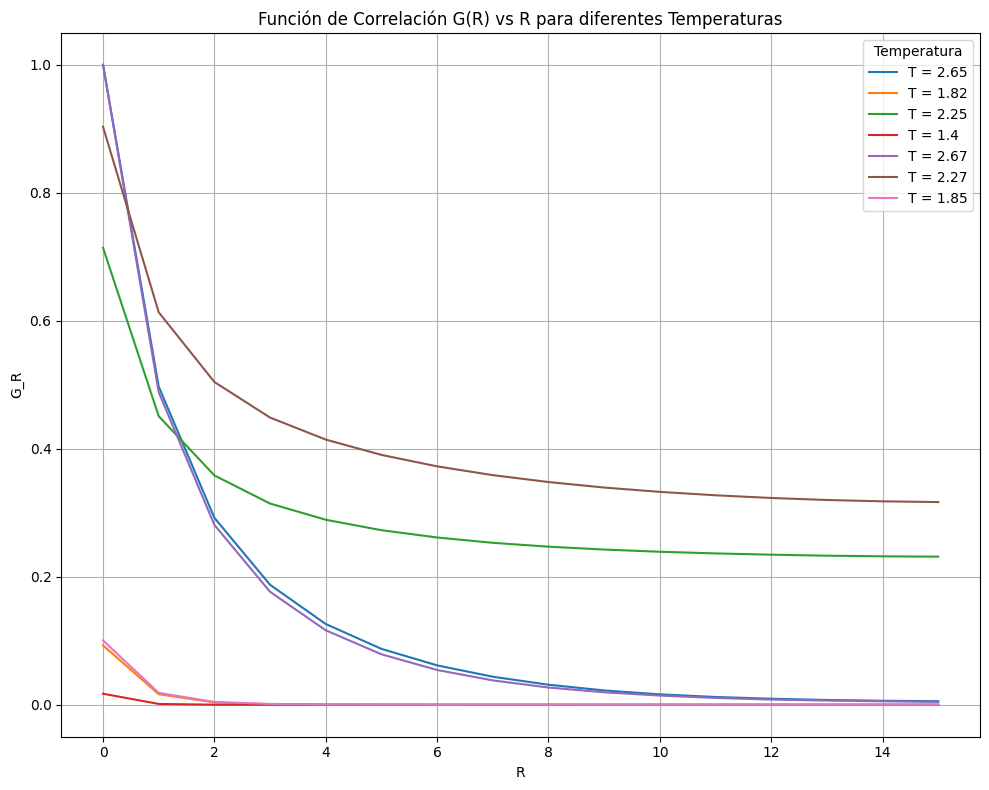

In [6]:
unique_temperatures = datos2['T'].unique()
# Select the first 7 unique temperatures, or fewer if there aren't 7
selected_temperatures = unique_temperatures[:7]

plt.figure(figsize=(10, 8))

for temp in selected_temperatures:
    # Filter data for the current temperature
    filtered_data_temp = datos2[datos2['T'] == temp]

    # Plot G_R vs R
    sns.lineplot(x='R', y='G_R', data=filtered_data_temp, label=f'T = {temp}')

plt.title('Función de Correlación G(R) vs R para diferentes Temperaturas')
plt.xlabel('R')
plt.ylabel('G_R')
plt.legend(title='Temperatura')
plt.grid(True)
plt.tight_layout()
plt.show()

##Longitud de correlacion

In [7]:
path3 = '/content/drive/MyDrive/Colab Notebooks/Simulaciones/resultados_xi_ejercicio_2.csv'
datos3 = pd.read_csv(path3)
datos3.head()

,T,Xi
0,2.65,3.094252
1,1.82,1.206816
2,2.25,27.269192
3,1.40,0.712070
4,2.67,2.996992


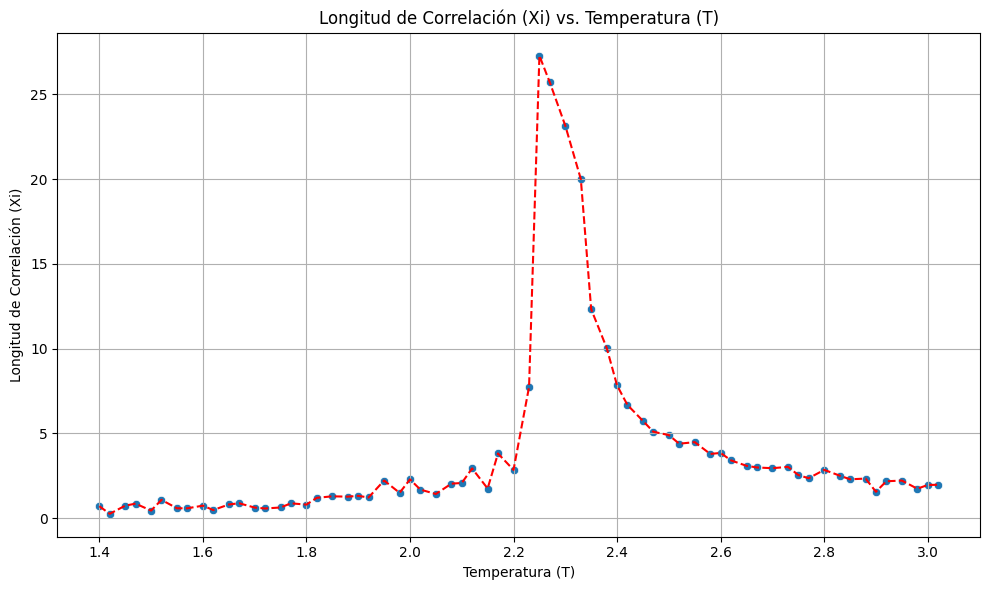

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='T', y='Xi', data=datos3)
sns.lineplot(x='T', y='Xi', data=datos3, color='red', linestyle='--') # Optional: Add a line to connect points or show trend
plt.title('Longitud de Correlación (Xi) vs. Temperatura (T)')
plt.xlabel('Temperatura (T)')
plt.ylabel('Longitud de Correlación (Xi)')
plt.grid(True)
plt.tight_layout()
plt.show()